# VinDr-Mammo: EDA for cancer detection classification
Sections: 1 Load and sanity checks, 2 Breast-level labels, 3 Study-level checks and leakage, 4 Findings and boxes, 5 DICOM metadata, 6 Images on disk, 7 Visual samples, 8 Summary

In [6]:
import os, ast, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
sns.set_style('whitegrid')

BREAST_CSV = '/kaggle/input/datasets/dalveersinghrathore/annotation/VinDr_breast-level_annotations.csv'
FIND_CSV = '/kaggle/input/datasets/dalveersinghrathore/annotation/VinDr_finding_annotations.csv'
META_CSV = '/kaggle/input/datasets/dalveersinghrathore/annotation/vinDr_metadata.csv'
IMG_DIR = '/kaggle/input/datasets/shantanughosh/vindr-mammogram-dataset-dicom-to-png/images_png'
OUT = '/kaggle/working/'


## 1. Load and sanity checks

In [7]:
breast = pd.read_csv(BREAST_CSV)
find = pd.read_csv(FIND_CSV)
meta = pd.read_csv(META_CSV)

for name, df in [('breast', breast), ('find', find), ('meta', meta)]:
    print('=' * 80)
    print(name, df.shape)
    display(df.head(3))
    print('Missing values per column:')
    print(df.isna().sum()[df.isna().sum() > 0])
    print('Fully duplicated rows:', df.duplicated().sum())


breast (20000, 10)


,study_id,series_id,image_id,laterality,view_position,height,width,breast_birads,breast_density,split
0,b8d273e8601f348d3664778dae0e7e0b,b36517b9cbbcfd286a7ae04f643af97a,d8125545210c08e1b1793a5af6458ee2,L,CC,3518,2800,BI-RADS 2,DENSITY C,training
1,b8d273e8601f348d3664778dae0e7e0b,b36517b9cbbcfd286a7ae04f643af97a,290c658f4e75a3f83ec78a847414297c,L,MLO,3518,2800,BI-RADS 2,DENSITY C,training
2,b8d273e8601f348d3664778dae0e7e0b,b36517b9cbbcfd286a7ae04f643af97a,cd0fc7bc53ac632a11643ac4cc91002a,R,CC,3518,2800,BI-RADS 2,DENSITY C,training


Missing values per column:
Series([], dtype: int64)
Fully duplicated rows: 0
find (20486, 16)


,study_id,series_id,image_id,laterality,view_position,height,width,breast_birads,breast_density,finding_categories,finding_birads,xmin,ymin,xmax,ymax,split
0,48575a27b7c992427041a82fa750d3fa,26de4993fa6b8ae50a91c8baf49b92b0,4e3a578fe535ea4f5258d3f7f4419db8,R,CC,3518,2800,BI-RADS 4,DENSITY C,['Mass'],BI-RADS 4,2355.139893,1731.640015,2482.979980,1852.750000,training
1,48575a27b7c992427041a82fa750d3fa,26de4993fa6b8ae50a91c8baf49b92b0,dac39351b0f3a8c670b7f8dc88029364,R,MLO,3518,2800,BI-RADS 4,DENSITY C,['Mass'],BI-RADS 4,2386.679932,1240.609985,2501.800049,1354.040039,training
2,75e8e48933289d70b407379a564f8594,853b70e7e6f39133497909d9ca4c756d,c83f780904f25eacb44e9030f32c66e1,R,CC,3518,2800,BI-RADS 3,DENSITY C,['Global Asymmetry'],BI-RADS 3,2279.179932,1166.510010,2704.439941,2184.260010,training


Missing values per column:
finding_birads    18357
xmin              18232
ymin              18232
xmax              18232
ymax              18232
dtype: int64
Fully duplicated rows: 0
meta (20000, 21)


,SOP Instance UID,Series Instance UID,SOP Instance UID.1,Patient's Age,View Position,Image Laterality,Photometric Interpretation,Rows,Columns,Imager Pixel Spacing,Pixel Spacing,Pixel Padding Value,Pixel Padding Range Limit,Window Center,Window Width,Rescale Intercept,Rescale Slope,Rescale Type,Window Center & Width Explanation,Manufacturer,Manufacturer's Model Name
0,d8125545210c08e1b1793a5af6458ee2,b36517b9cbbcfd286a7ae04f643af97a,d8125545210c08e1b1793a5af6458ee2,053Y,CC,L,MONOCHROME2,3518,2800,"[0.085, 0.085]",NaN,0,NaN,1662,1500,0,1,US,linear LUT,SIEMENS,Mammomat Inspiration
1,290c658f4e75a3f83ec78a847414297c,b36517b9cbbcfd286a7ae04f643af97a,290c658f4e75a3f83ec78a847414297c,053Y,MLO,L,MONOCHROME2,3518,2800,"[0.085, 0.085]",NaN,0,NaN,1664,1500,0,1,US,linear LUT,SIEMENS,Mammomat Inspiration
2,cd0fc7bc53ac632a11643ac4cc91002a,b36517b9cbbcfd286a7ae04f643af97a,cd0fc7bc53ac632a11643ac4cc91002a,053Y,CC,R,MONOCHROME2,3518,2800,"[0.085, 0.085]",NaN,0,NaN,1600,1500,0,1,US,linear LUT,SIEMENS,Mammomat Inspiration


Missing values per column:
Patient's Age                 2260
Pixel Spacing                16128
Pixel Padding Range Limit    19040
dtype: int64
Fully duplicated rows: 0


In [8]:
# The metadata file has a duplicated column name 'SOP Instance UID'. Rename the first three by position.
print(list(meta.columns[:5]))
new_cols = list(meta.columns)
new_cols[0] = 'study_id'
new_cols[1] = 'series_id'
new_cols[2] = 'image_id'
meta.columns = new_cols

# check the IDs actually line up with the annotation files
print('image_id overlap meta vs breast:', meta['image_id'].isin(breast['image_id']).mean())
print('study_id overlap meta vs breast:', meta['study_id'].isin(breast['study_id']).mean())
print('unique images (breast):', breast['image_id'].nunique(), '| unique studies:', breast['study_id'].nunique())
print('unique images (find):', find['image_id'].nunique())
print('unique images (meta):', meta['image_id'].nunique())
print('images in find but not in breast:', (~find['image_id'].isin(breast['image_id'])).sum())


['SOP Instance UID', 'Series Instance UID', 'SOP Instance UID.1', "Patient's Age", 'View Position']
image_id overlap meta vs breast: 1.0
study_id overlap meta vs breast: 0.0
unique images (breast): 20000 | unique studies: 5000
unique images (find): 20000
unique images (meta): 20000
images in find but not in breast: 0


## 2. Breast-level labels

In [9]:
# numeric BI-RADS and binary target
breast['birads'] = breast['breast_birads'].astype(str).str.extract('([0-9])')[0].astype(float)
print(breast['breast_birads'].value_counts(dropna=False).sort_index())

# Working definition: BI-RADS 4 or 5 = suspicious/positive, 1-3 = negative. No biopsy truth exists in this data.
breast['label'] = (breast['birads'] >= 4).astype(int)

print('\nSplit counts:')
print(breast['split'].value_counts())
print('\nBI-RADS by split (counts):')
print(pd.crosstab(breast['birads'], breast['split']))
print('\nBI-RADS by split (column %):')
print((pd.crosstab(breast['birads'], breast['split'], normalize='columns') * 100).round(2))
print('\nBinary label overall:')
print(breast['label'].value_counts())
print('Positive rate overall: %.4f' % breast['label'].mean())
print(breast.groupby('split')['label'].agg(['count', 'sum', 'mean']))


breast_birads
BI-RADS 1    13406
BI-RADS 2     4676
BI-RADS 3      930
BI-RADS 4      762
BI-RADS 5      226
Name: count, dtype: int64

Split counts:
split
training    16000
test         4000
Name: count, dtype: int64

BI-RADS by split (counts):
split   test  training
birads                
1.0     2682     10724
2.0      934      3742
3.0      186       744
4.0      152       610
5.0       46       180

BI-RADS by split (column %):
split    test  training
birads                 
1.0     67.05     67.03
2.0     23.35     23.39
3.0      4.65      4.65
4.0      3.80      3.81
5.0      1.15      1.12

Binary label overall:
label
0    19012
1      988
Name: count, dtype: int64
Positive rate overall: 0.0494
          count  sum      mean
split                         
test       4000  198  0.049500
training  16000  790  0.049375


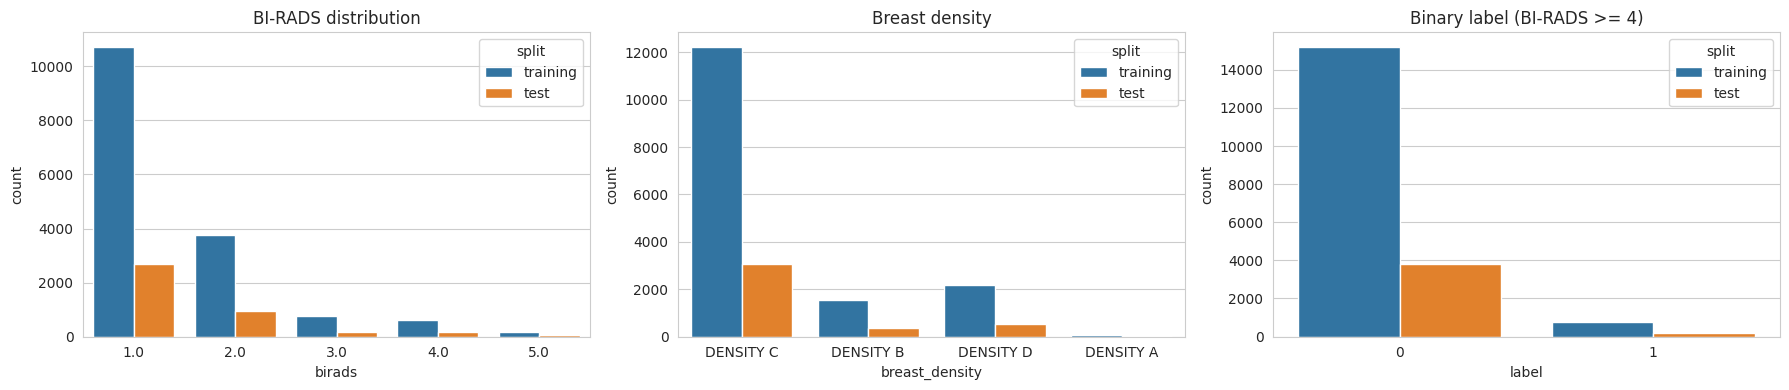

breast_density
DENSITY C    15292
DENSITY D     2700
DENSITY B     1908
DENSITY A      100
Name: count, dtype: int64

Laterality:
laterality
L    10000
R    10000
Name: count, dtype: int64

View position:
view_position
CC     10001
MLO     9999
Name: count, dtype: int64

Laterality x View:
view_position    CC   MLO
laterality               
L              5001  4999
R              5000  5000


In [10]:
fig, ax = plt.subplots(1, 3, figsize=(18, 4))
sns.countplot(data=breast, x='birads', hue='split', ax=ax[0])
ax[0].set_title('BI-RADS distribution')
sns.countplot(data=breast, x='breast_density', hue='split', ax=ax[1])
ax[1].set_title('Breast density')
sns.countplot(data=breast, x='label', hue='split', ax=ax[2])
ax[2].set_title('Binary label (BI-RADS >= 4)')
plt.tight_layout()
plt.savefig(OUT + 'eda_labels.png', dpi=100)
plt.show()

print(breast['breast_density'].value_counts(dropna=False))
print('\nLaterality:'); print(breast['laterality'].value_counts())
print('\nView position:'); print(breast['view_position'].value_counts())
print('\nLaterality x View:'); print(pd.crosstab(breast['laterality'], breast['view_position']))


In [11]:
# positive rate across subgroups: shows confounders the model could shortcut on
for col in ['breast_density', 'laterality', 'view_position']:
    print('Positive rate by', col)
    print(breast.groupby(col)['label'].agg(['count', 'sum', 'mean']).round(4))
    print()

print('BI-RADS x density:')
print(pd.crosstab(breast['birads'], breast['breast_density']))

print('\nImage size (height, width) counts:')
print(breast.groupby(['height', 'width']).size().sort_values(ascending=False).head(15))
breast['aspect'] = breast['height'] / breast['width']
print(breast['aspect'].describe())
print('\nSize by label:')
print(breast.groupby('label')[['height', 'width']].describe().T)


Positive rate by breast_density
                count  sum    mean
breast_density                    
DENSITY A         100    6  0.0600
DENSITY B        1908  130  0.0681
DENSITY C       15292  786  0.0514
DENSITY D        2700   66  0.0244

Positive rate by laterality
            count  sum    mean
laterality                    
L           10000  516  0.0516
R           10000  472  0.0472

Positive rate by view_position
               count  sum    mean
view_position                    
CC             10001  494  0.0494
MLO             9999  494  0.0494

BI-RADS x density:
breast_density  DENSITY A  DENSITY B  DENSITY C  DENSITY D
birads                                                    
1.0                    80       1326      10088       1912
2.0                     8        404       3624        640
3.0                     6         48        794         82
4.0                     6         60        636         60
5.0                     0         70        150          6

Ima

## 3. Study-level checks and leakage

In [12]:
per_study = breast.groupby('study_id').agg(n_images=('image_id', 'count'),
                                           n_splits=('split', 'nunique'),
                                           max_birads=('birads', 'max'),
                                           any_pos=('label', 'max'))
print('Images per study:'); print(per_study['n_images'].value_counts())
print('\nStudies appearing in more than one split (leakage):', (per_study['n_splits'] > 1).sum())
print('\nStudies by split:')
print(breast.drop_duplicates('study_id')['split'].value_counts())
print('\nStudy-level positive rate (any breast BI-RADS>=4): %.4f' % per_study['any_pos'].mean())
print(per_study['max_birads'].value_counts().sort_index())

# Are labels consistent between the two views of the same breast?
grp = breast.groupby(['study_id', 'laterality'])
cons = grp['birads'].nunique()
print('\nBreasts (study+laterality):', len(cons))
print('Breasts where CC and MLO have different BI-RADS:', (cons > 1).sum())
print('Breasts with an image count other than 2:', (grp.size() != 2).sum())

# left vs right breast label cross-tab
lr = breast.groupby(['study_id', 'laterality'])['birads'].max().unstack()
print('\nLeft vs Right max BI-RADS:')
print(pd.crosstab(lr['L'], lr['R']))


Images per study:
n_images
4    5000
Name: count, dtype: int64

Studies appearing in more than one split (leakage): 0

Studies by split:
split
training    4000
test        1000
Name: count, dtype: int64

Study-level positive rate (any breast BI-RADS>=4): 0.0962
max_birads
1.0    2515
2.0    1568
3.0     436
4.0     368
5.0     113
Name: count, dtype: int64

Breasts (study+laterality): 10000
Breasts where CC and MLO have different BI-RADS: 0
Breasts with an image count other than 2: 0

Left vs Right max BI-RADS:
R     1.0  2.0  3.0  4.0  5.0
L                            
1.0  2515  534  142  100   37
2.0   563  471   59   62   18
3.0   150   70   15    5    1
4.0   111   75    7    8    3
5.0    36   15    1    2    0


## 4. Finding annotations (boxes)

In [13]:
def parse_cats(x):
    if isinstance(x, str) and x.strip().startswith('['):
        try:
            return ast.literal_eval(x)
        except Exception:
            return [x]
    return [x]

find['cats'] = find['finding_categories'].apply(parse_cats)
find['birads'] = find['breast_birads'].astype(str).str.extract('([0-9])')[0].astype(float)
find['f_birads'] = find['finding_birads'].astype(str).str.extract('([0-9])')[0].astype(float)

print('Raw finding_categories examples:')
print(find['finding_categories'].value_counts().head(15))

fx = find.explode('cats')
print('\nCategory counts (one row per category):')
print(fx['cats'].value_counts())
print('\nCategory x finding BI-RADS:')
print(pd.crosstab(fx['cats'], fx['f_birads']))
print('\nCategory x split:')
print(pd.crosstab(fx['cats'], fx['split']))
print('\nFinding BI-RADS value counts:')
print(find['finding_birads'].value_counts(dropna=False))
print('\nRows with missing box coordinates:', find['xmin'].isna().sum())


Raw finding_categories examples:
finding_categories
['No Finding']                                              18232
['Mass']                                                     1123
['Suspicious Calcification']                                  402
['Focal Asymmetry']                                           232
['Architectural Distortion']                                   95
['Asymmetry']                                                  90
['Suspicious Calcification', 'Mass']                           82
['Suspicious Lymph Node']                                      57
['Skin Thickening']                                            38
['Suspicious Calcification', 'Focal Asymmetry']                31
['Global Asymmetry']                                           24
['Suspicious Calcification', 'Architectural Distortion']       13
['Nipple Retraction']                                          12
['Skin Retraction']                                             7
['Skin Thickening', 'Nip

Boxes: 2254
Boxes outside image bounds: 42
Boxes with non-positive size: 0

Box size stats (pixels and fraction of image):
                bw           bh          area     rel_area
count  2254.000000  2254.000000  2.254000e+03  2254.000000
mean    266.717689   301.039647  1.102781e+05     0.012567
std     164.904810   217.381742  1.591963e+05     0.019671
min      24.219971    16.219971  5.263373e+02     0.000053
5%       75.420363    79.025989  6.418216e+03     0.000657
25%     147.344749   156.250000  2.371385e+04     0.002531
50%     227.921997   243.958466  5.551554e+04     0.006142
75%     344.194687   381.072449  1.273657e+05     0.014414
95%     606.992572   728.878478  4.227158e+05     0.045972
max    1120.452947  1982.445000  1.991525e+06     0.276358

Relative box area by category:
                           count     mean      std      min      25%      50%  \
cat                                                                             
Architectural Distortion    98.0  

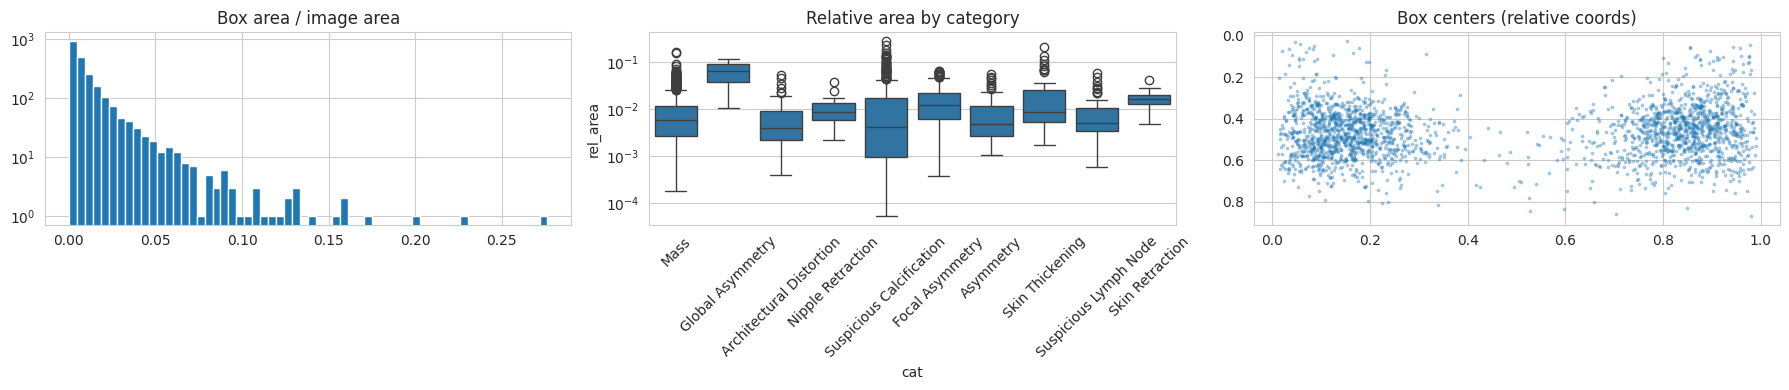


Boxes per image:
count    1768.000000
mean        1.274887
std         0.663719
min         1.000000
25%         1.000000
50%         1.000000
75%         1.000000
max         7.000000
dtype: float64
1    1430
2     239
3      62
4      28
5       7
6       1
7       1
Name: count, dtype: int64


In [14]:
box = find.dropna(subset=['xmin', 'ymin', 'xmax', 'ymax']).copy()
box['bw'] = box['xmax'] - box['xmin']
box['bh'] = box['ymax'] - box['ymin']
box['area'] = box['bw'] * box['bh']
box['rel_area'] = box['area'] / (box['height'] * box['width'])
box['cx'] = (box['xmin'] + box['xmax']) / 2 / box['width']
box['cy'] = (box['ymin'] + box['ymax']) / 2 / box['height']
box['cat'] = box['cats'].apply(lambda c: c[0] if len(c) > 0 else 'NA')

print('Boxes:', len(box))
print('Boxes outside image bounds:', ((box['xmax'] > box['width']) | (box['ymax'] > box['height']) | (box['xmin'] < 0) | (box['ymin'] < 0)).sum())
print('Boxes with non-positive size:', ((box['bw'] <= 0) | (box['bh'] <= 0)).sum())
print('\nBox size stats (pixels and fraction of image):')
print(box[['bw', 'bh', 'area', 'rel_area']].describe(percentiles=[.05, .25, .5, .75, .95]))
print('\nRelative box area by category:')
print(box.groupby('cat')['rel_area'].describe().round(5))

fig, ax = plt.subplots(1, 3, figsize=(18, 4))
ax[0].hist(box['rel_area'], bins=60); ax[0].set_title('Box area / image area'); ax[0].set_yscale('log')
sns.boxplot(data=box, x='cat', y='rel_area', ax=ax[1]); ax[1].set_yscale('log'); ax[1].tick_params(axis='x', rotation=45); ax[1].set_title('Relative area by category')
ax[2].scatter(box['cx'], box['cy'], s=3, alpha=0.3); ax[2].invert_yaxis(); ax[2].set_title('Box centers (relative coords)')
plt.tight_layout(); plt.savefig(OUT + 'eda_boxes.png', dpi=100); plt.show()

print('\nBoxes per image:')
print(box.groupby('image_id').size().describe())
print(box.groupby('image_id').size().value_counts().sort_index())


In [15]:
# link findings back to breast-level labels
imgs_with_box = set(box['image_id'])
breast['has_box'] = breast['image_id'].isin(imgs_with_box).astype(int)
print('Image BI-RADS vs has bounding box:')
print(pd.crosstab(breast['birads'], breast['has_box']))
print('\nPositive images (BI-RADS>=4) without a box:', ((breast['label'] == 1) & (breast['has_box'] == 0)).sum())
print('Negative images with a box:', ((breast['label'] == 0) & (breast['has_box'] == 1)).sum())

# does breast_birads in the finding file agree with the breast file?
chk = find[['image_id', 'birads']].drop_duplicates().merge(breast[['image_id', 'birads']], on='image_id', suffixes=('_f', '_b'))
print('\nBI-RADS mismatches between finding and breast files:', (chk['birads_f'] != chk['birads_b']).sum())

# which finding categories appear on positive images
pos_ids = set(breast.loc[breast['label'] == 1, 'image_id'])
print('\nCategories on positive images:')
print(fx[fx['image_id'].isin(pos_ids)]['cats'].value_counts())


Image BI-RADS vs has bounding box:
has_box      0    1
birads             
1.0      13406    0
2.0       4664   12
3.0        126  804
4.0         34  728
5.0          2  224

Positive images (BI-RADS>=4) without a box: 36
Negative images with a box: 816

BI-RADS mismatches between finding and breast files: 0

Categories on positive images:
cats
Mass                        696
Suspicious Calcification    477
Focal Asymmetry             137
Architectural Distortion     99
Suspicious Lymph Node        54
Skin Thickening              47
No Finding                   36
Nipple Retraction            33
Asymmetry                    15
Skin Retraction              13
Global Asymmetry              6
Name: count, dtype: int64


## 5. DICOM metadata

In [16]:
m = meta.copy()
m['age'] = m["Patient's Age"].astype(str).str.extract('([0-9]+)')[0].astype(float)
m['spacing'] = m['Imager Pixel Spacing'].astype(str).str.extract('([0-9]+[.][0-9]+)')[0].astype(float)

print('Age stats:'); print(m['age'].describe())
print('Missing age:', m['age'].isna().sum())
print('\nManufacturer:'); print(m['Manufacturer'].value_counts(dropna=False))
print('\nModel:'); print(m["Manufacturer's Model Name"].value_counts(dropna=False))
print('\nPhotometric Interpretation:'); print(m['Photometric Interpretation'].value_counts(dropna=False))
print('\nImager pixel spacing:'); print(m['Imager Pixel Spacing'].value_counts(dropna=False).head(10))
print('\nPixel Padding Value:'); print(m['Pixel Padding Value'].value_counts(dropna=False).head())
print('\nWindow Center:'); print(m['Window Center'].value_counts(dropna=False).head(10))
print('\nWindow Width:'); print(m['Window Width'].value_counts(dropna=False).head(10))
print('\nRescale Type / Slope / Intercept:')
print(m[['Rescale Type', 'Rescale Slope', 'Rescale Intercept']].drop_duplicates())
print('\nRows x Columns:')
print(m.groupby(['Rows', 'Columns']).size().sort_values(ascending=False).head(10))


Age stats:
count    17740.000000
mean        44.119053
std         11.698422
min          0.000000
25%         38.000000
50%         45.000000
75%         51.000000
max         88.000000
Name: age, dtype: float64
Missing age: 2260

Manufacturer:
Manufacturer
SIEMENS              15244
Planmed               3796
IMS s.r.l.             736
IMS GIOTTO S.p.A.      224
Name: count, dtype: int64

Model:
Manufacturer's Model Name
Mammomat Inspiration    15244
Planmed Nuance           3796
GIOTTO CLASS              628
GIOTTO IMAGE 3DL          332
Name: count, dtype: int64

Photometric Interpretation:
Photometric Interpretation
MONOCHROME2    16204
MONOCHROME1     3796
Name: count, dtype: int64

Imager pixel spacing:
Imager Pixel Spacing
[0.085, 0.085]      15244
[0.0850, 0.0850]     3796
[0.0828, 0.0828]      404
[0.0814, 0.0814]      332
[0.083, 0.083]        224
Name: count, dtype: int64

Pixel Padding Value:
Pixel Padding Value
0        16204
10000     3796
Name: count, dtype: int64

Wind

Images with no metadata match: 0

Positive rate by manufacturer:
                   count  sum    mean
Manufacturer                         
IMS GIOTTO S.p.A.    224   18  0.0804
IMS s.r.l.           736  190  0.2582
Planmed             3796  156  0.0411
SIEMENS            15244  624  0.0409

Positive rate by model:
                           count  sum    mean
Manufacturer's Model Name                    
GIOTTO CLASS                 628   54  0.0860
GIOTTO IMAGE 3DL             332  154  0.4639
Mammomat Inspiration       15244  624  0.0409
Planmed Nuance              3796  156  0.0411

Positive rate by photometric interpretation:
                            count  sum    mean
Photometric Interpretation                    
MONOCHROME1                  3796  156  0.0411
MONOCHROME2                 16204  832  0.0513

Manufacturer by split:
split              test  training
Manufacturer                     
IMS GIOTTO S.p.A.    40       184
IMS s.r.l.          120       616
Planmed     

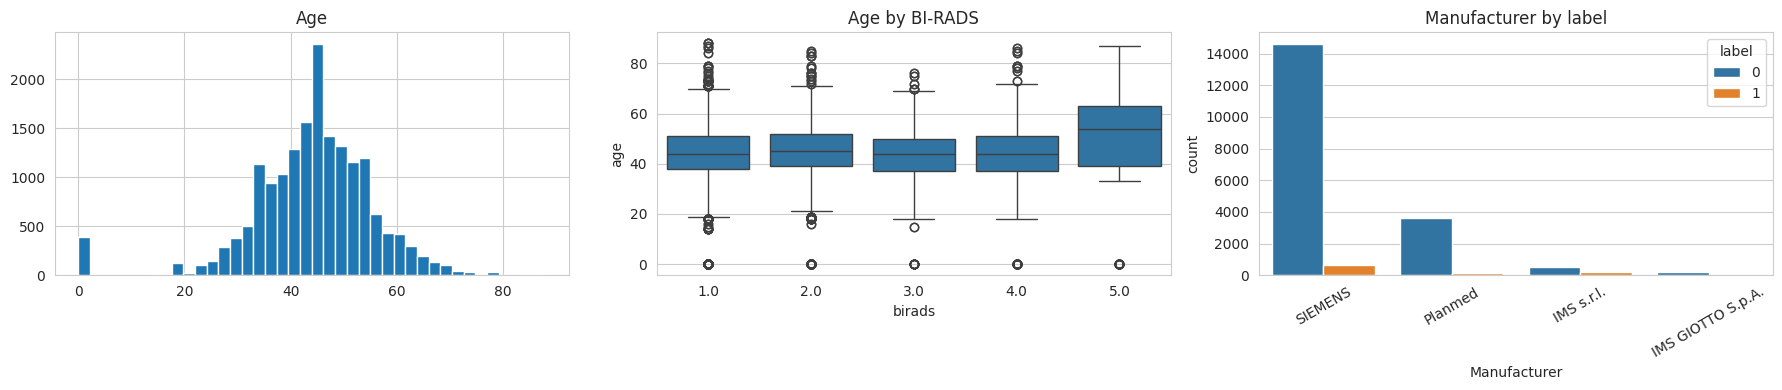

In [17]:
cols = ['image_id', 'age', 'spacing', 'Manufacturer', "Manufacturer's Model Name", 'Photometric Interpretation', 'Window Center', 'Window Width']
df = breast.merge(m[cols], on='image_id', how='left')
print('Images with no metadata match:', df['Manufacturer'].isna().sum())

print('\nPositive rate by manufacturer:')
print(df.groupby('Manufacturer')['label'].agg(['count', 'sum', 'mean']).round(4))
print('\nPositive rate by model:')
print(df.groupby("Manufacturer's Model Name")['label'].agg(['count', 'sum', 'mean']).round(4))
print('\nPositive rate by photometric interpretation:')
print(df.groupby('Photometric Interpretation')['label'].agg(['count', 'sum', 'mean']).round(4))
print('\nManufacturer by split:')
print(pd.crosstab(df['Manufacturer'], df['split']))

df['age_bin'] = pd.cut(df['age'], bins=[0, 40, 50, 60, 70, 120])
print('\nPositive rate by age bin:')
print(df.groupby('age_bin')['label'].agg(['count', 'sum', 'mean']).round(4))
print('\nAge by BI-RADS:')
print(df.groupby('birads')['age'].describe().round(1))

fig, ax = plt.subplots(1, 3, figsize=(18, 4))
ax[0].hist(df['age'].dropna(), bins=40); ax[0].set_title('Age')
sns.boxplot(data=df, x='birads', y='age', ax=ax[1]); ax[1].set_title('Age by BI-RADS')
sns.countplot(data=df, x='Manufacturer', hue='label', ax=ax[2]); ax[2].tick_params(axis='x', rotation=30); ax[2].set_title('Manufacturer by label')
plt.tight_layout(); plt.savefig(OUT + 'eda_metadata.png', dpi=100); plt.show()


## 6. Images on disk

In [18]:
# build image_id -> path map by walking the folder (works whether or not files are nested by study)
path_map = {}
for root, dirs, files in os.walk(IMG_DIR):
    for f in files:
        if f.lower().endswith('.png'):
            path_map[os.path.splitext(f)[0]] = os.path.join(root, f)
print('PNG files found:', len(path_map))
print('Example:', list(path_map.items())[:2])

breast['path'] = breast['image_id'].map(path_map)
print('Images in CSV without a file:', breast['path'].isna().sum())
print('Files without a CSV row:', len(set(path_map) - set(breast['image_id'])))
print('Studies with folder count (top-level folders):', len([d for d in os.listdir(IMG_DIR) if os.path.isdir(os.path.join(IMG_DIR, d))]))


PNG files found: 20000
Example: [('a85636bc3e9a44de2cfe0341fa2b2421', '/kaggle/input/datasets/shantanughosh/vindr-mammogram-dataset-dicom-to-png/images_png/c3a4083c5d1cbae24bf78b95465c89b1/a85636bc3e9a44de2cfe0341fa2b2421.png'), ('39e183171ffaf61b0d40bb198f013a7c', '/kaggle/input/datasets/shantanughosh/vindr-mammogram-dataset-dicom-to-png/images_png/c3a4083c5d1cbae24bf78b95465c89b1/39e183171ffaf61b0d40bb198f013a7c.png')]
Images in CSV without a file: 0
Files without a CSV row: 0
Studies with folder count (top-level folders): 5000


Mode / dtype:
mode  dtype
L     uint8    300
dtype: int64

PNG size matches CSV height/width: 0.0

Pixel stats:
          min     max    mean  fg_frac  fg_mean  corner_mean
count  300.00  300.00  300.00   300.00   300.00       300.00
mean     0.42  220.87  107.52     0.75   142.54        74.86
std      1.89   22.17   20.84     0.10    15.05        17.48
min      0.00  176.00   73.94     0.54   100.25        37.25
25%      0.00  203.00   93.23     0.67   136.50        63.50
50%      0.00  213.00  101.14     0.73   139.92        70.21
75%      0.00  247.00  116.79     0.83   144.38        80.96
max     17.00  255.00  197.43     1.00   222.85       156.76

Stats by label:
         mean  fg_frac  fg_mean     max
label                                  
0      103.62     0.73   141.27  215.69
1      111.43     0.77   143.81  226.05

Images whose max is far below the dtype max (possible dim/odd windowing): 0


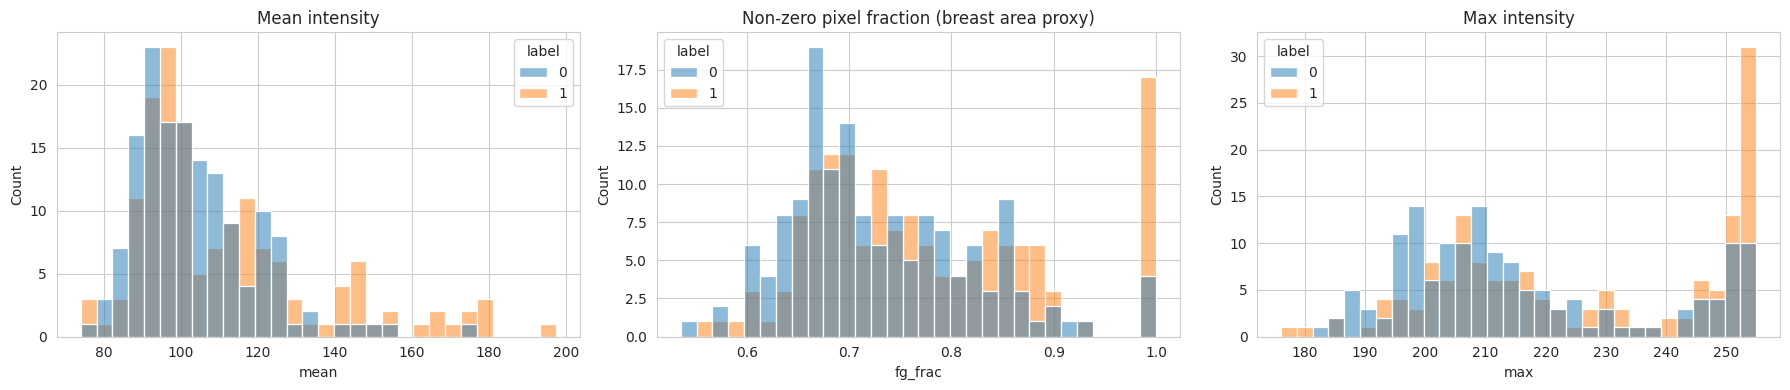

In [19]:
# pixel statistics on a random sample, balanced a bit towards positives
avail = breast.dropna(subset=['path'])
sample = pd.concat([avail[avail['label'] == 1].sample(min(150, int(avail['label'].sum()))),
                    avail[avail['label'] == 0].sample(150)])
rows = []
for _, r in sample.iterrows():
    im = Image.open(r['path'])
    a = np.array(im)
    fg = a[a > 0]
    rows.append({'image_id': r['image_id'], 'label': r['label'], 'mode': im.mode, 'dtype': str(a.dtype),
                 'png_h': a.shape[0], 'png_w': a.shape[1], 'csv_h': r['height'], 'csv_w': r['width'],
                 'min': int(a.min()), 'max': int(a.max()), 'mean': float(a.mean()),
                 'fg_frac': float((a > 0).mean()), 'fg_mean': float(fg.mean()) if fg.size else 0.0,
                 'corner_mean': float(np.mean([a[:50, :50].mean(), a[:50, -50:].mean(), a[-50:, :50].mean(), a[-50:, -50:].mean()]))})
px = pd.DataFrame(rows)
print('Mode / dtype:'); print(px.groupby(['mode', 'dtype']).size())
print('\nPNG size matches CSV height/width:', ((px['png_h'] == px['csv_h']) & (px['png_w'] == px['csv_w'])).mean())
print('\nPixel stats:'); print(px[['min', 'max', 'mean', 'fg_frac', 'fg_mean', 'corner_mean']].describe().round(2))
print('\nStats by label:'); print(px.groupby('label')[['mean', 'fg_frac', 'fg_mean', 'max']].mean().round(2))
print('\nImages whose max is far below the dtype max (possible dim/odd windowing):', (px['max'] < 0.5 * px['max'].max()).sum())

fig, ax = plt.subplots(1, 3, figsize=(18, 4))
sns.histplot(data=px, x='mean', hue='label', bins=30, ax=ax[0]); ax[0].set_title('Mean intensity')
sns.histplot(data=px, x='fg_frac', hue='label', bins=30, ax=ax[1]); ax[1].set_title('Non-zero pixel fraction (breast area proxy)')
sns.histplot(data=px, x='max', hue='label', bins=30, ax=ax[2]); ax[2].set_title('Max intensity')
plt.tight_layout(); plt.savefig(OUT + 'eda_pixels.png', dpi=100); plt.show()


## 7. Visual samples (with finding boxes)

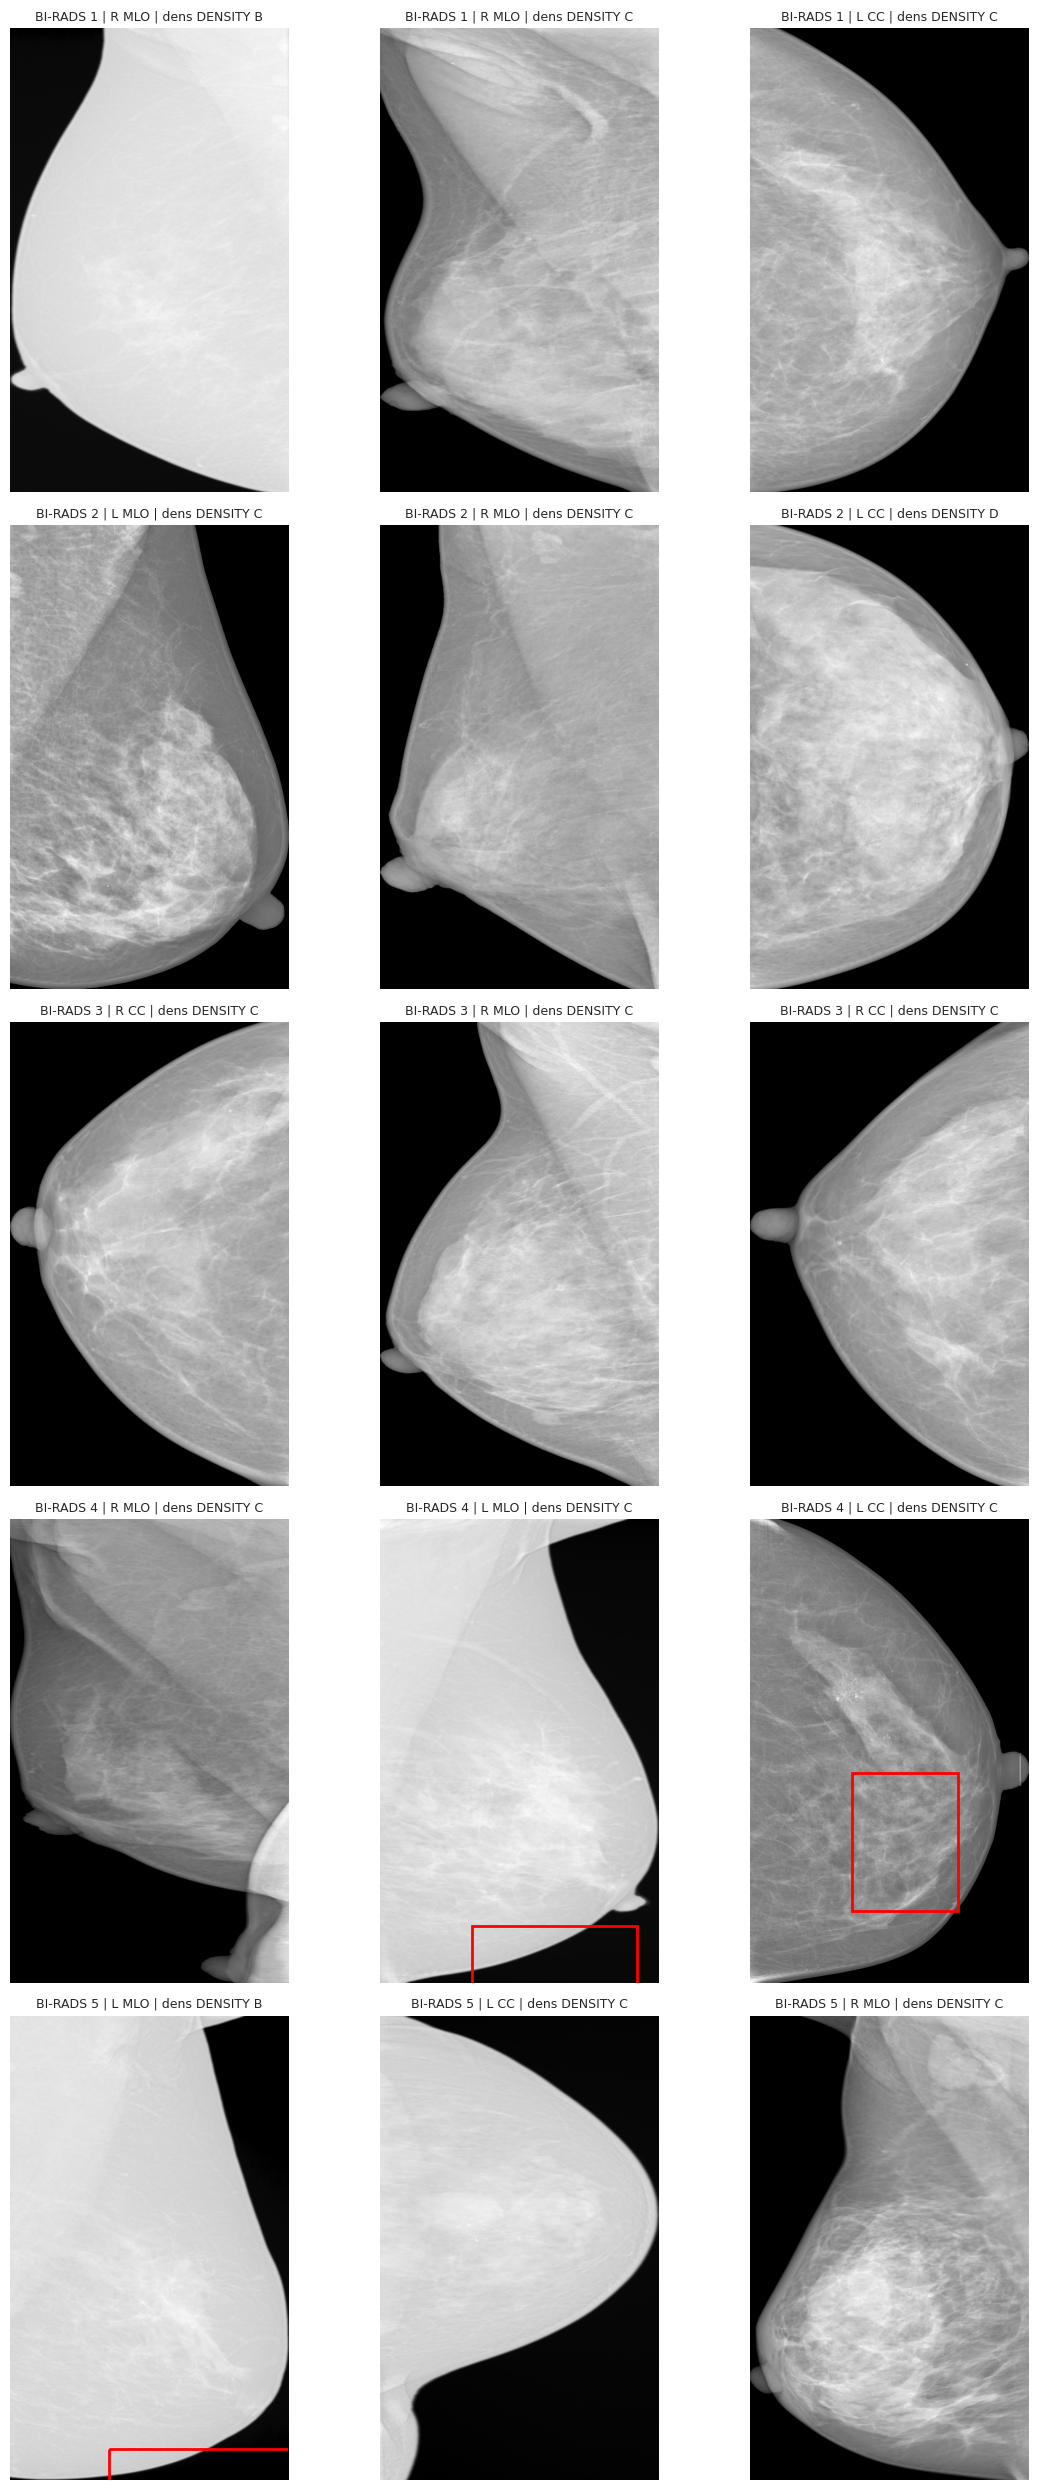

In [20]:
import matplotlib.patches as patches
classes = sorted(avail['birads'].dropna().unique())
n_per = 3
fig, axes = plt.subplots(len(classes), n_per, figsize=(4 * n_per, 5 * len(classes)))
for i, c in enumerate(classes):
    pool = avail[avail['birads'] == c]
    ch = pool.sample(min(n_per, len(pool)))
    for j in range(n_per):
        ax = axes[i, j]
        ax.axis('off')
        if j >= len(ch):
            continue
        r = ch.iloc[j]
        ax.imshow(Image.open(r['path']), cmap='gray')
        for _, b in box[box['image_id'] == r['image_id']].iterrows():
            ax.add_patch(patches.Rectangle((b['xmin'], b['ymin']), b['bw'], b['bh'], fill=False, edgecolor='red', linewidth=2))
        ax.set_title('BI-RADS %d | %s %s | dens %s' % (c, r['laterality'], r['view_position'], r['breast_density']), fontsize=9)
plt.tight_layout(); plt.savefig(OUT + 'eda_samples.png', dpi=80); plt.show()


## 8. Summary of what matters for modelling

In [21]:
n_pos = int(breast['label'].sum()); n_neg = len(breast) - n_pos
tr = breast[breast['split'] == 'training']; te = breast[breast['split'] != 'training']
print('Images: %d | studies: %d' % (len(breast), breast['study_id'].nunique()))
print('Positive (BI-RADS>=4): %d | Negative: %d | pos rate %.4f | suggested pos_weight ~ %.1f' % (n_pos, n_neg, n_pos / len(breast), n_neg / max(n_pos, 1)))
print('Train pos rate %.4f | Test pos rate %.4f' % (tr['label'].mean(), te['label'].mean()))
print('Studies in multiple splits (leakage):', int((per_study['n_splits'] > 1).sum()))
print('Most common image size:', breast.groupby(['height', 'width']).size().idxmax())
print('Median box area as fraction of image: %.4f' % box['rel_area'].median())
print('Images with boxes:', int(breast['has_box'].sum()))
print('Median age: %s' % m['age'].median())
print('Manufacturers:', m['Manufacturer'].nunique(), '| photometric modes:', m['Photometric Interpretation'].unique().tolist())

summary = pd.DataFrame({'item': ['images', 'studies', 'positives', 'negatives', 'pos_rate'],
                        'value': [len(breast), breast['study_id'].nunique(), n_pos, n_neg, n_pos / len(breast)]})
summary.to_csv(OUT + 'eda_summary.csv', index=False)
breast.drop(columns=['path']).to_csv(OUT + 'breast_with_labels.csv', index=False)
print('Saved plots and CSVs to', OUT)


Images: 20000 | studies: 5000
Positive (BI-RADS>=4): 988 | Negative: 19012 | pos rate 0.0494 | suggested pos_weight ~ 19.2
Train pos rate 0.0494 | Test pos rate 0.0495
Studies in multiple splits (leakage): 0
Most common image size: (np.int64(3518), np.int64(2800))
Median box area as fraction of image: 0.0061
Images with boxes: 1768
Median age: 45.0
Manufacturers: 4 | photometric modes: ['MONOCHROME2', 'MONOCHROME1']
Saved plots and CSVs to /kaggle/working/
